In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

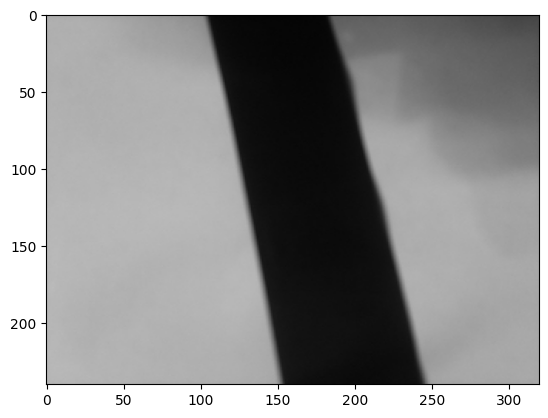

In [2]:
image = cv2.imread('line1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

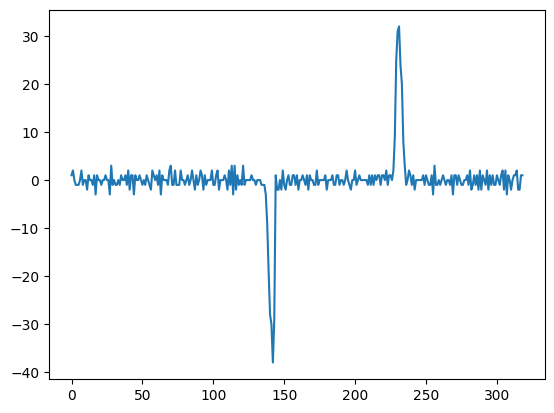

In [3]:
row = gray[180].astype(np.int32)
diff = np.diff(row)
plt.plot(diff)

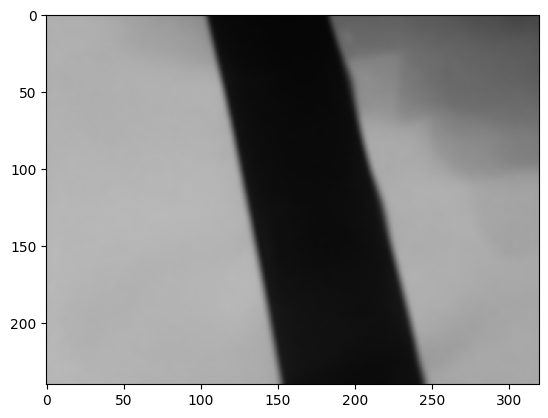

In [4]:
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))

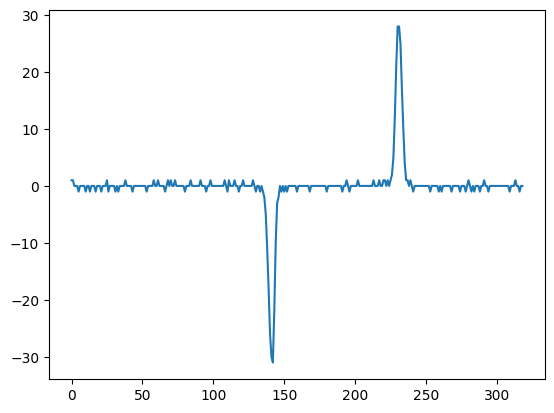

In [5]:
b_row = blurred[180].astype(np.int32)
b_diff = np.diff(b_row)
plt.plot(b_diff)

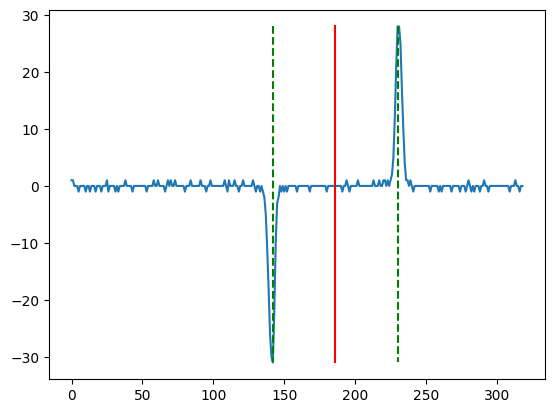

In [7]:
max_d = np.amax(b_diff)
min_d = np.amin(b_diff)
highest = np.where(b_diff == max_d)[0][0]
lowest = np.where(b_diff == min_d)[0][0]
middle = (highest + lowest) // 2
plt.plot(b_diff)
plt.plot([middle, middle], [max_d, min_d], "r-")
plt.plot([lowest, lowest], [max_d, min_d], "g--")
plt.plot([highest, highest], [max_d, min_d], "g--")

In [14]:
class LineFinder:
    def __init__(self, image, row_number):
        self.image = image
        self.gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.blurred = cv2.blur(self.gray, (9, 9), 0)
        # self.blurred = cv2.blur(self.blurred, (5, 5), 0)
        row = self.blurred[row_number].astype(np.int32)
        self.diff = np.diff(row)

        max_d = np.amax(self.diff)
        min_d = np.amin(self.diff)
        self.highest = np.where(self.diff == max_d)[0][0]
        self.lowest = np.where(self.diff == min_d)[0][0]
        if max_d < 10:
            self.middle = None
        else:
            self.middle = (self.highest + self.lowest) // 2

    def plot_image(self):
        plt.imshow(cv2.cvtColor(self.blurred, cv2.COLOR_BGR2RGB))
        # plt.imshow(cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB))
        if self.middle is None:
            plt.title("No line detected")
        else:
            plt.plot([self.middle, self.middle], [0, 240], "r-")
            plt.plot([self.lowest, self.lowest], [0, 240], "g--")
            plt.plot([self.highest, self.highest], [0, 240], "g--")
        plt.plot([0, 320], [180, 180], "b--")
    
    def plot_diff(self):
        # Set the 
        plt.plot(self.diff)
        if self.middle is not None:
            plt.plot([self.middle, self.middle], [np.amax(self.diff), np.amin(self.diff)], "r-")
            plt.plot([self.lowest, self.lowest], [np.amax(self.diff), np.amin(self.diff)], "g--")
            plt.plot([self.highest, self.highest], [np.amax(self.diff), np.amin(self.diff)], "g--")

    def plot_both(self):
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title('Line Finder Image Plot')
        self.plot_image()
        plt.subplot(1, 2, 2)
        plt.title('Line Finder Diff Plot')
        self.plot_diff()
        # set the height of the diff plot to match the image plot
        plt.ylim(-20, 20)
        
        plt.tight_layout()
        plt.show()
    


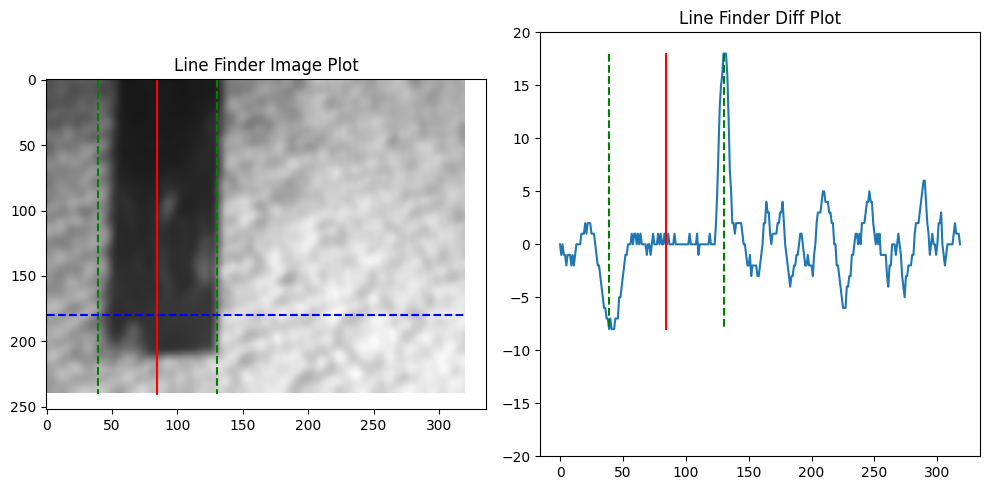

In [15]:
carpet_line = cv2.imread('carpet_line1 2.jpg')
carpet_line = cv2.resize(carpet_line, (320, 240))
line = LineFinder(carpet_line, 180)
line.plot_both()

Processing curve_1.png...


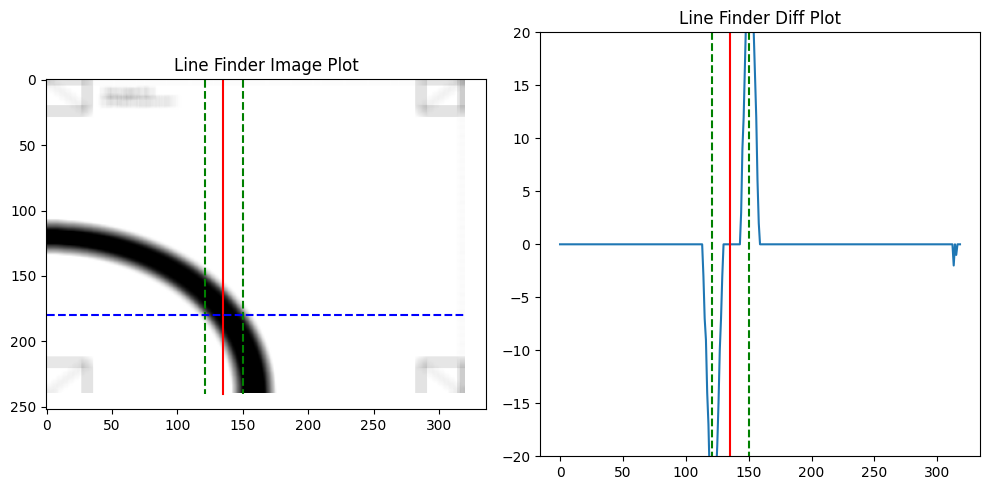

Processing curve_2.png...


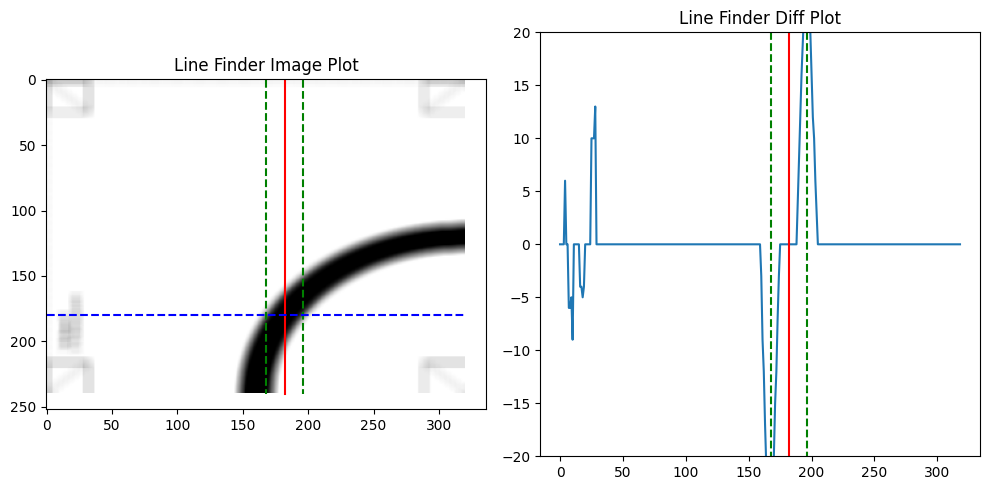

Processing long_curve.png...


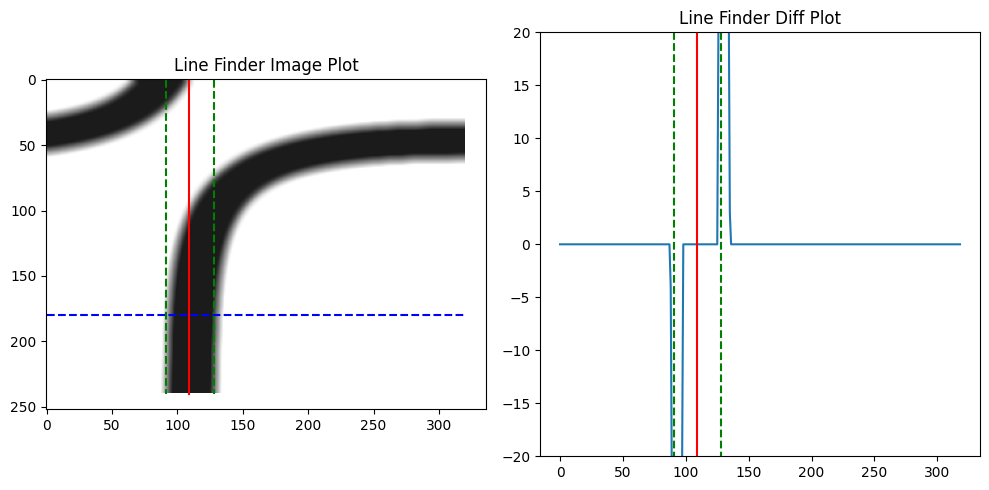

Processing line1.jpg...


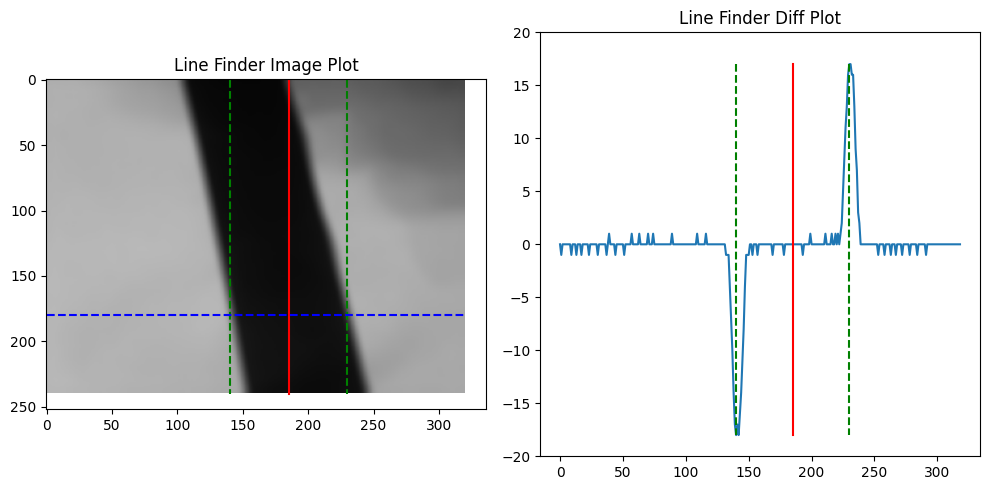

Processing line2.jpg...


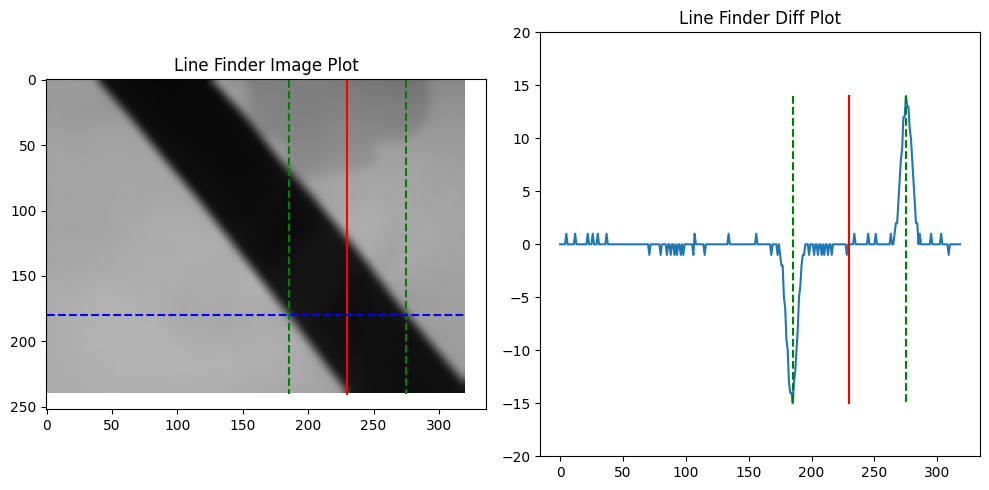

Processing carpet_line1 2.jpg...


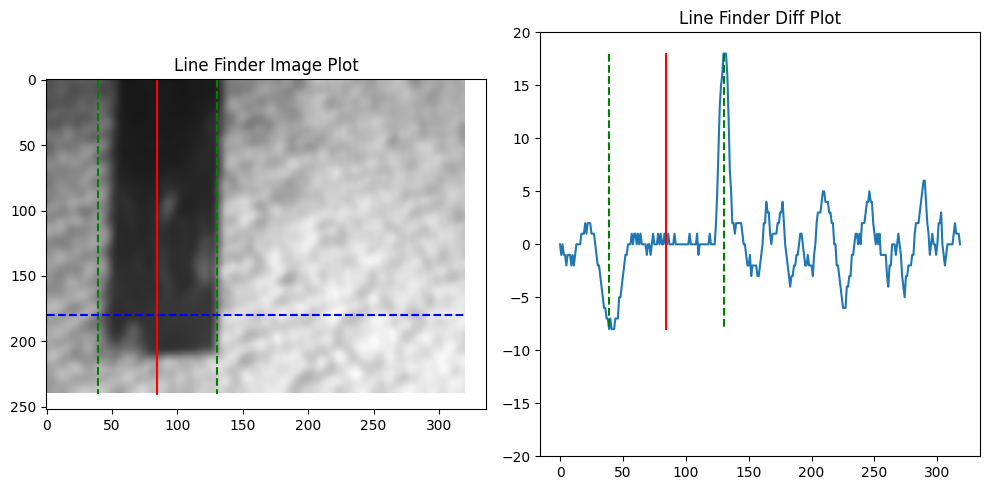

Processing carpet_noline.jpg...


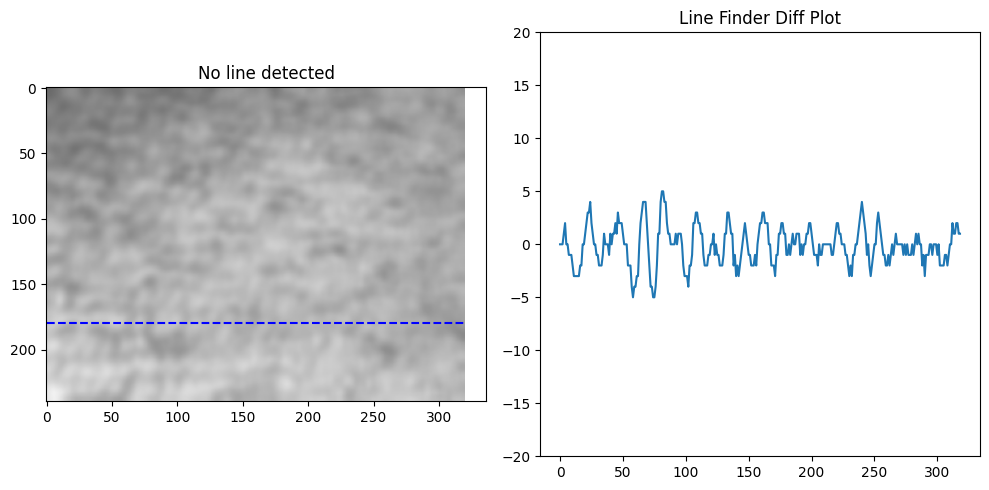

Processing late_bend.png...


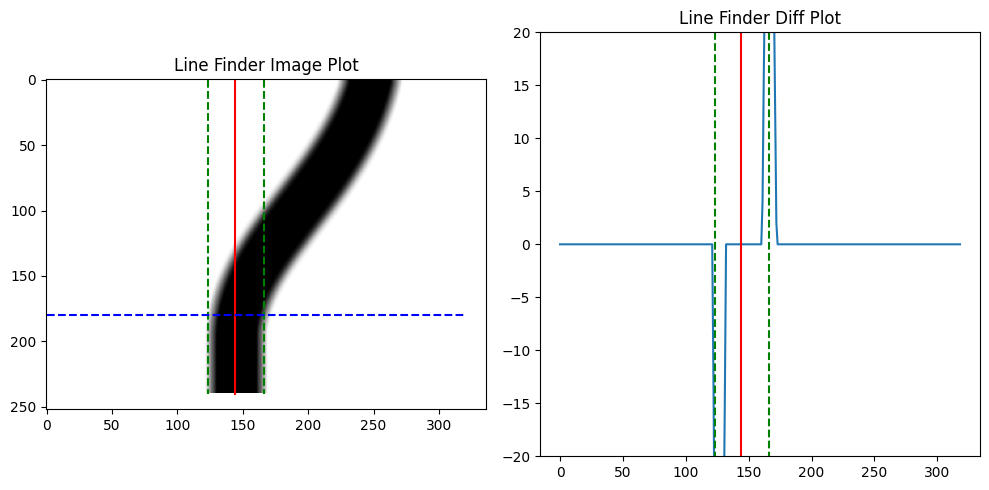

In [16]:
def try_line_finder(image_path, row_number=180):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return
    image = cv2.resize(image, (320, 240))
    line_finder = LineFinder(image, row_number)
    line_finder.plot_both()

image_names = ['curve_1.png', 'curve_2.png', 'long_curve.png', 'line1.jpg', 'line2.jpg', 'carpet_line1 2.jpg', 'carpet_noline.jpg',
               'late_bend.png'
               ]
for image_name in image_names:
    print(f"Processing {image_name}...")
    try_line_finder(image_name, 180)


This might largely overlap with the notebook added into the book, with some more interesting images. It might not be relevant enough to keep.